In [1]:
import kagglehub
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from feature_engine.encoding import OneHotEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import os

mpl.rcParams['figure.dpi'] = 150

In [2]:
path = kagglehub.dataset_download("ahmeduzaki/wind-and-solar-energy-production-dataset")
data_path = os.listdir(path)[0]
full_path = os.path.join(path, data_path)
print(f"Full Path: {full_path}")

Full Path: C:\Users\ASUS\.cache\kagglehub\datasets\ahmeduzaki\wind-and-solar-energy-production-dataset\versions\1\Energy Production Dataset.csv


In [3]:
df = pd.read_csv(full_path)
df.head()

,Date,Start_Hour,End_Hour,Source,Day_of_Year,Day_Name,Month_Name,Season,Production
0,11/30/2025,21,22,Wind,334,Sunday,November,Fall,5281
1,11/30/2025,18,19,Wind,334,Sunday,November,Fall,3824
2,11/30/2025,16,17,Wind,334,Sunday,November,Fall,3824
3,11/30/2025,23,0,Wind,334,Sunday,November,Fall,6120
4,11/30/2025,6,7,Wind,334,Sunday,November,Fall,4387


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51864 entries, 0 to 51863
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         51864 non-null  object
 1   Start_Hour   51864 non-null  int64 
 2   End_Hour     51864 non-null  int64 
 3   Source       51864 non-null  object
 4   Day_of_Year  51864 non-null  int64 
 5   Day_Name     51864 non-null  object
 6   Month_Name   51864 non-null  object
 7   Season       51864 non-null  object
 8   Production   51864 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 3.6+ MB


In [5]:
df.describe()

,Start_Hour,End_Hour,Day_of_Year,Production
count,51864.000000,51864.000000,51864.000000,51864.000000
mean,11.500000,11.500000,180.798415,6215.069933
std,6.922253,6.922253,104.291387,3978.364965
min,0.000000,0.000000,1.000000,58.000000
25%,5.750000,5.750000,91.000000,3111.000000
50%,11.500000,11.500000,181.000000,5372.000000
75%,17.250000,17.250000,271.000000,8501.000000
max,23.000000,23.000000,366.000000,23446.000000


In [6]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

0       2025-11-30
1       2025-11-30
2       2025-11-30
3       2025-11-30
4       2025-11-30
           ...    
51859   2020-01-01
51860   2020-01-01
51861   2020-01-01
51862   2020-01-01
51863   2020-01-01
Name: Date, Length: 51864, dtype: datetime64[ns]

In [7]:
string_columns = df.select_dtypes(include='object').columns

for col in string_columns:
    print('-'*50, '\n')
    print(df[col].value_counts(), '\n')

-------------------------------------------------- 

Source
Wind     42484
Solar     9378
Mixed        2
Name: count, dtype: int64 

-------------------------------------------------- 

Day_Name
Sunday       7416
Saturday     7416
Friday       7416
Thursday     7416
Wednesday    7416
Tuesday      7392
Monday       7392
Name: count, dtype: int64 

-------------------------------------------------- 

Month_Name
October      4470
August       4464
July         4464
May          4464
January      4464
March        4458
November     4320
September    4320
June         4320
April        4320
February     4080
December     3720
Name: count, dtype: int64 

-------------------------------------------------- 

Season
Summer    13248
Spring    13242
Fall      13110
Winter    12264
Name: count, dtype: int64 



In [8]:
df.drop(index=df.query('Source == "Mixed"').index, inplace=True)

> Rows labeled as **"Mixed"** were removed due to their negligible frequency
> (2 observations) and lack of analytical relevance for wind vs solar comparison.

In [9]:
LABELS_FONT_SIZE = 10
TITLE_FONT_SIZE = 20
FONT_WEIGHT = 'bold'

## Research Questions

1. Which energy source (wind or solar) produced more total energy over the observed time period?

2. During which season was the highest amount of energy produced overall?

3. Which month recorded the highest energy production, and does this differ between wind and solar sources?

4. Are there any anomalies or unusual spikes/drops in energy production?


<h3>1. Which energy source (wind or solar) produced more total energy over the observed time period?</h3>

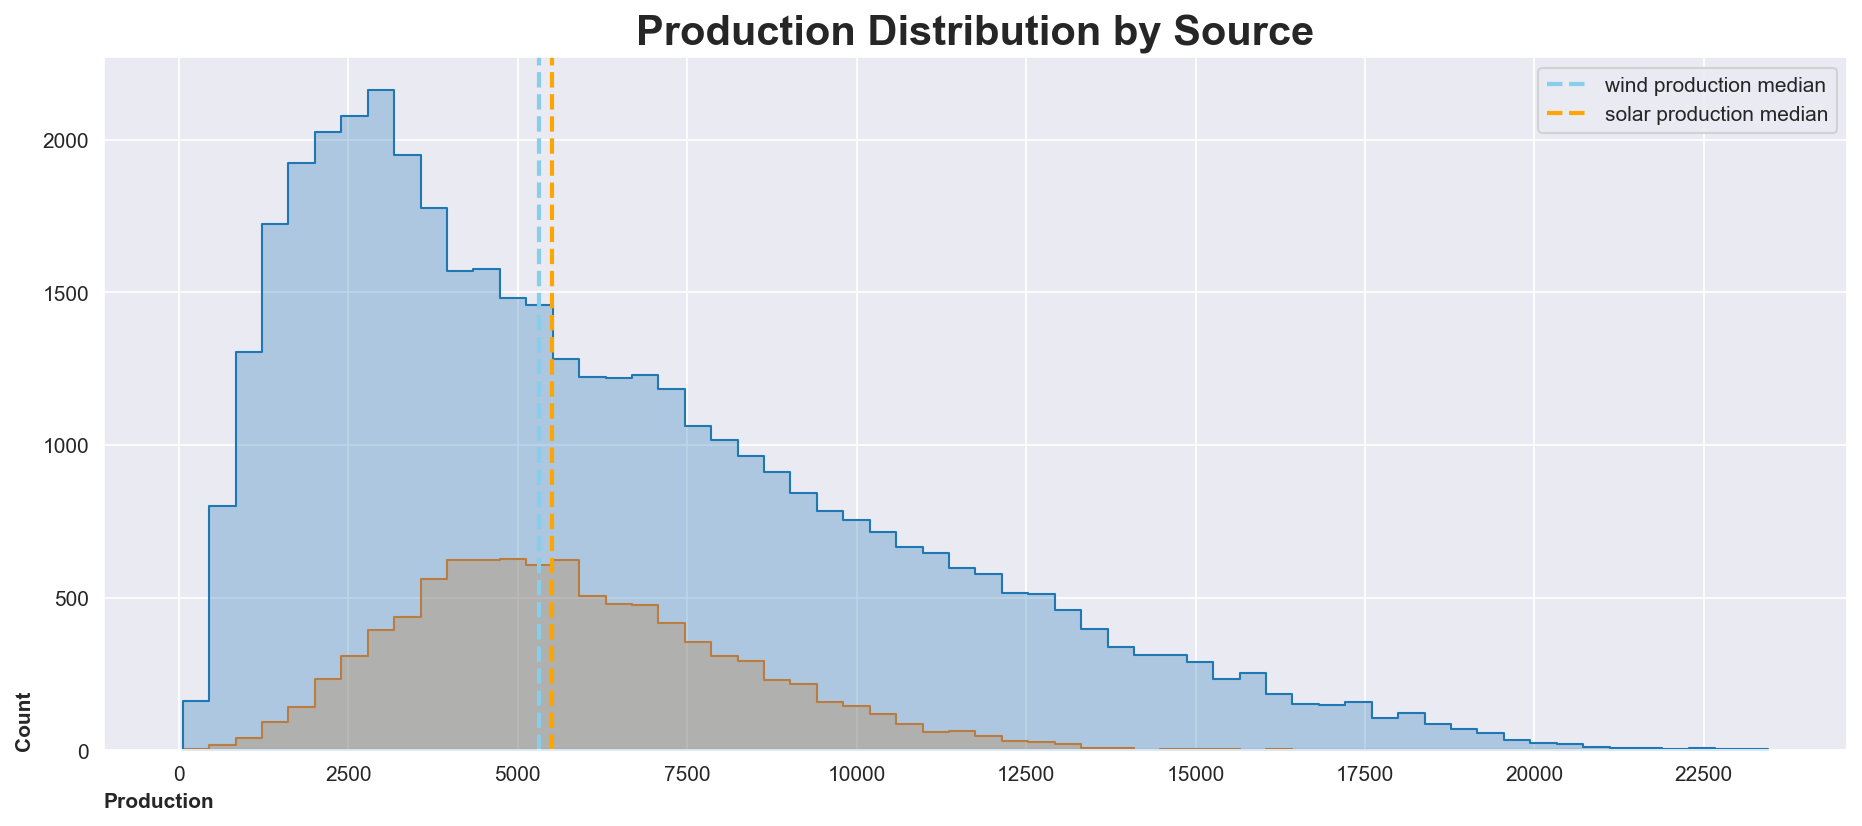

In [10]:
wind_production_median = df.query('Source == "Wind"')['Production'].median()
solar_production_median = df.query('Source == "Solar"')['Production'].median()

fig, ax = plt.subplots(figsize=(15, 6))
sns.histplot(
    data=df, x='Production',
    hue='Source', bins=60,
    alpha=0.3, element='step', stat='count',
    ax=ax
)

ax.axvline(x=wind_production_median, linestyle='--', linewidth=2, color='skyblue', label='wind production median')
ax.axvline(x=solar_production_median, linestyle='--', linewidth=2, color='orange', label='solar production median')

ax.set_title('Production Distribution by Source', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Production', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Count', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xticks(np.arange(0, max(df['Production']), 2500))
plt.legend()
plt.show()

<p>This chart illustrates the production distribution for wind and solar energy sources.
Wind energy shows a much wider distribution and higher variability, indicating that while it can achieve very high production levels, its output is less stable over time.

In contrast, solar energy production is more concentrated around its median value, suggesting greater stability and predictability.
The vertical dashed lines representing the median production levels indicate that although wind reaches higher extremes, the typical (median) production of wind and solar is relatively similar.</p>

<h3>2. During which season was the highest amount of energy produced overall?</h3>

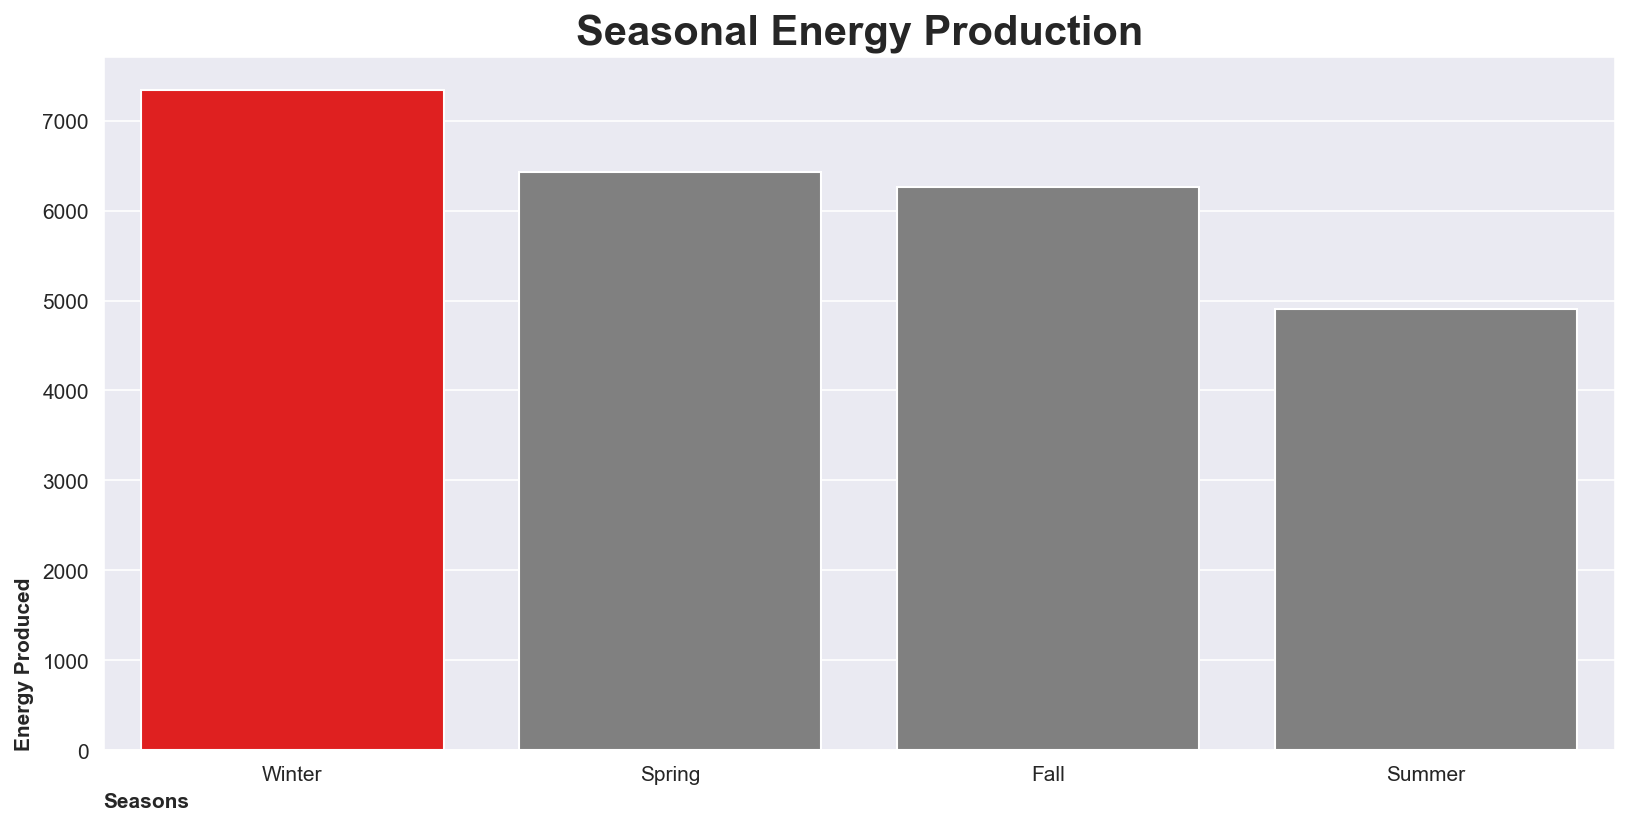

In [11]:
energy_produced_each_season = (df.groupby('Season', as_index=False)['Production'].mean()
                              .sort_values(by='Production', ascending=False).reset_index(drop=True))
energy_produced_each_season = energy_produced_each_season.assign(color=lambda x: x['Production']
                                                               .isin(x['Production'].nlargest(1))
                                                               .map({True: 'red', False: 'gray'}))

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=energy_produced_each_season, 
    x='Season', 
    y='Production', 
    hue='color',
    palette={
        'red': 'red',
        'gray': 'gray'
    }
)

ax.set_title('Seasonal Energy Production', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Seasons', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Energy Produced', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.legend().set_visible(False)
plt.show()

<p>This chart shows the total energy production across different seasons.
The results indicate that winter has the highest energy production, while summer records the lowest production levels.

The increased energy production during winter may be associated with higher demand for heating systems, as residential and industrial energy consumption typically rises during colder months. As a result, energy generation systems are likely operated at higher capacity to meet this seasonal demand.

In contrast, lower energy production during summer could be explained by reduced heating needs and changes in overall energy consumption patterns.
Overall, the chart highlights the significant role of seasonality in influencing energy production levels.</p>

<h3>3. Which month recorded the highest energy production, and does this differ between wind and solar sources?</h3>

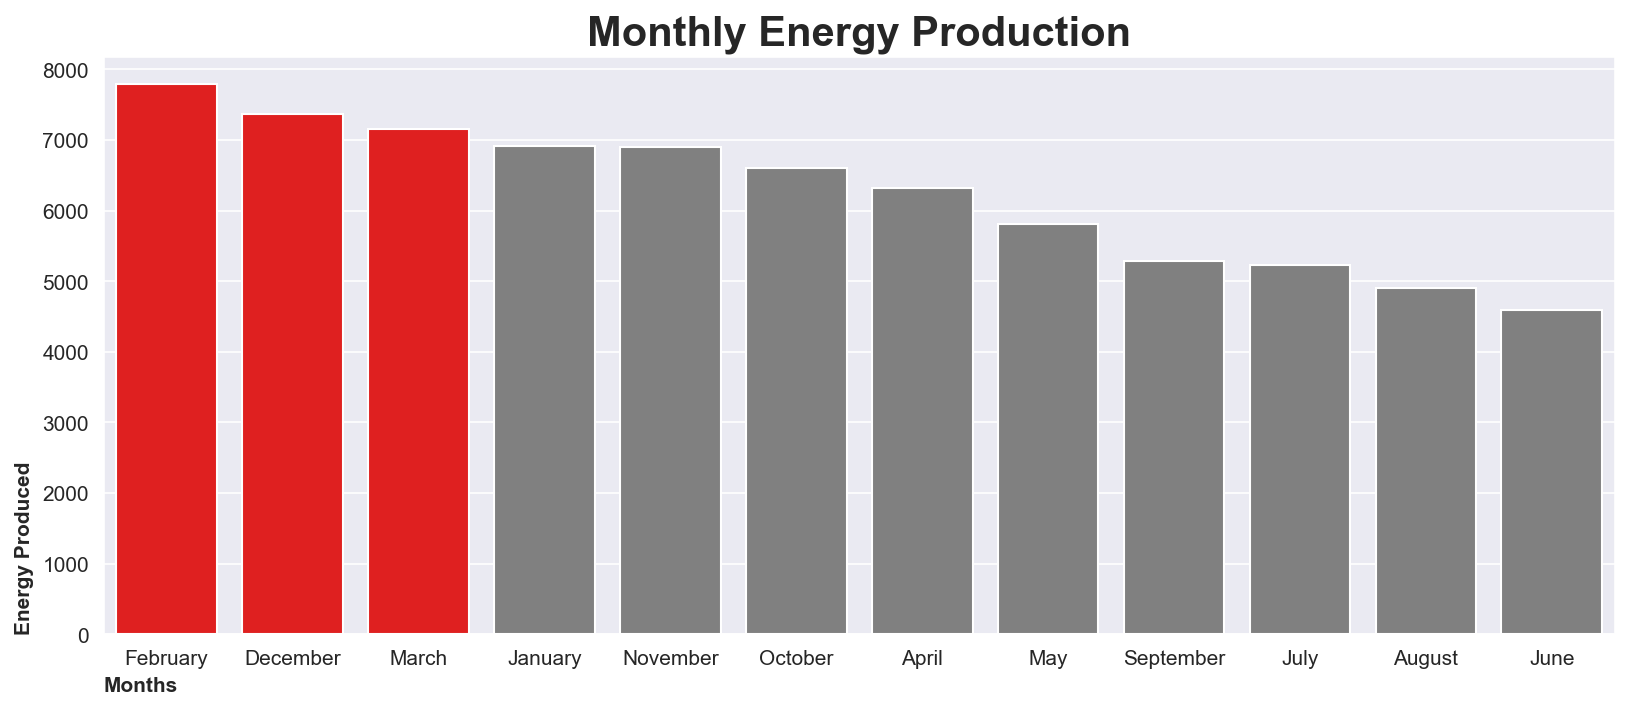

In [12]:
energy_produced_each_month = (df.groupby('Month_Name', as_index=False)['Production'].mean()
                              .sort_values(by='Production', ascending=False).reset_index(drop=True))
energy_produced_each_month = energy_produced_each_month.assign(color=lambda x: x['Production']
                                                               .isin(x['Production'].nlargest(3))
                                                               .map({True: 'red', False: 'gray'}))

fig, ax = plt.subplots(figsize=(13, 5))
sns.barplot(
    data=energy_produced_each_month, 
    x='Month_Name', 
    y='Production', 
    hue='color',
    palette={
        'red': 'red',
        'gray': 'gray'
    }
)

ax.set_title('Monthly Energy Production', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Months', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Energy Produced', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
plt.legend().set_visible(False)
plt.show()

<p>This chart presents the total energy production aggregated by month.
The results show that February and December, both winter months, have the highest energy production, which is consistent with the earlier seasonal analysis indicating that winter is the peak production season.

Additionally, March, which belongs to the spring season, records the second-highest monthly energy production overall. This suggests that elevated energy production levels extend beyond winter and continue into early spring.

Overall, the observed monthly pattern aligns well with the seasonal trends, confirming that energy production is highest during colder months and gradually decreases toward summer. This behavior is consistent with increased energy demand during winter and early spring periods.</p>

In [13]:
Q1 = np.quantile(df['Production'], 0.25)
Q3 = np.quantile(df['Production'], 0.75)
IQR = Q3 - Q1

alpha = 1.5

upper_bound = Q3 + alpha * IQR
lower_bound = Q1 - alpha * IQR

df['is_outlier'] = np.where(df['Production'] > upper_bound, 1, 0)

print(f'Outliers Percent: {df['is_outlier'].sum() / df.shape[0] * 100:.2f}%')

Outliers Percent: 1.83%


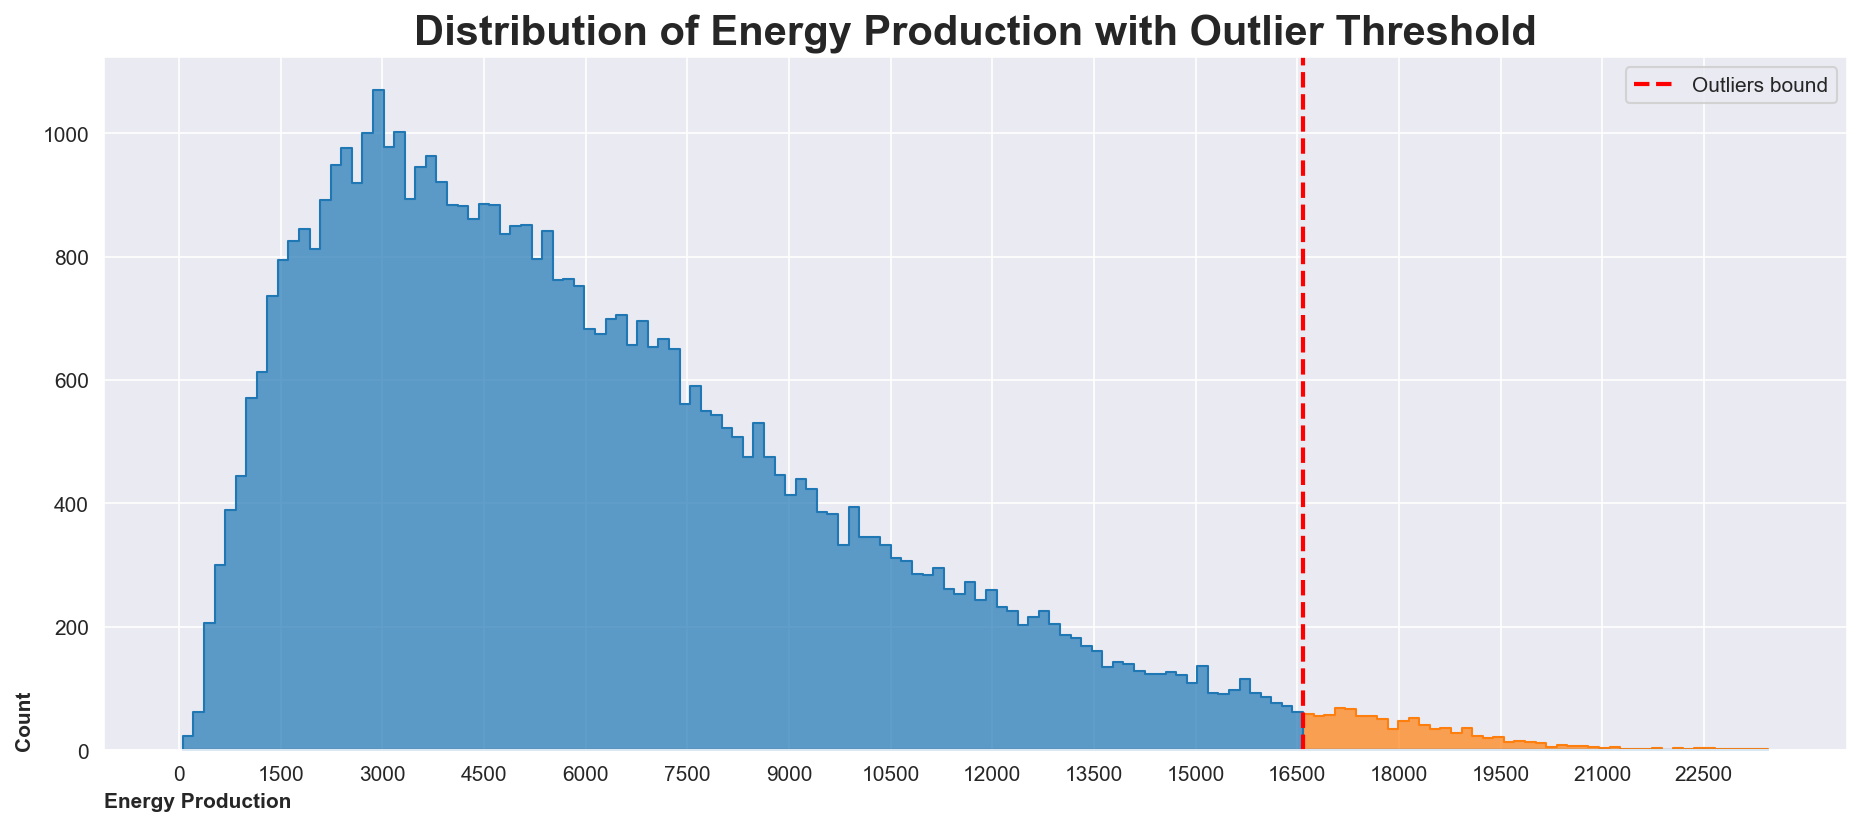

In [14]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.histplot(
    data=df, x='Production',
    bins=150,
    element='step', stat='count',
    hue='is_outlier',
    alpha=0.7,
    ax=ax
)

ax.axvline(x=upper_bound, linestyle='--', linewidth=2, color='red', label='Outliers bound')

ax.set_title('Distribution of Energy Production with Outlier Threshold', fontsize=TITLE_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xlabel('Energy Production', loc='left', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_ylabel('Count', loc='bottom', fontsize=LABELS_FONT_SIZE, fontweight=FONT_WEIGHT)
ax.set_xticks(np.arange(0, max(df['Production']), 1500))
plt.legend()
plt.show()

<p>As shown in the chart, energy production values above 16,500 are identified as anomalies based on the defined outlier threshold. The dashed vertical line represents this upper boundary, beyond which observations deviate significantly from the main distribution. These high-production values occur infrequently and lie in the extreme right tail of the distribution, indicating unusually large production events compared to typical behavior.</p>

<h1>Training Predictive Model</h1>

In [15]:
df = df[df['is_outlier'] == 0]

columns = ['Source', 'Season', 'Month_Name', 'Day_of_Year']

X = df[columns]
y = df['Production']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

ohe = OneHotEncoder(variables=columns[:-1])
X_train_transformed = ohe.fit_transform(X_train)
X_test_transformed = ohe.transform(X_test)

In [38]:
model = Sequential([
    Input(shape=(X_train_transformed.shape[1],)),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    

    Dense(1)
])

model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                │ (None, 128)            │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,225 (79.00 KB)

 Trainable params: 19,713 (77.00 KB)

 Non-trainable params: 512 (2.00 KB)

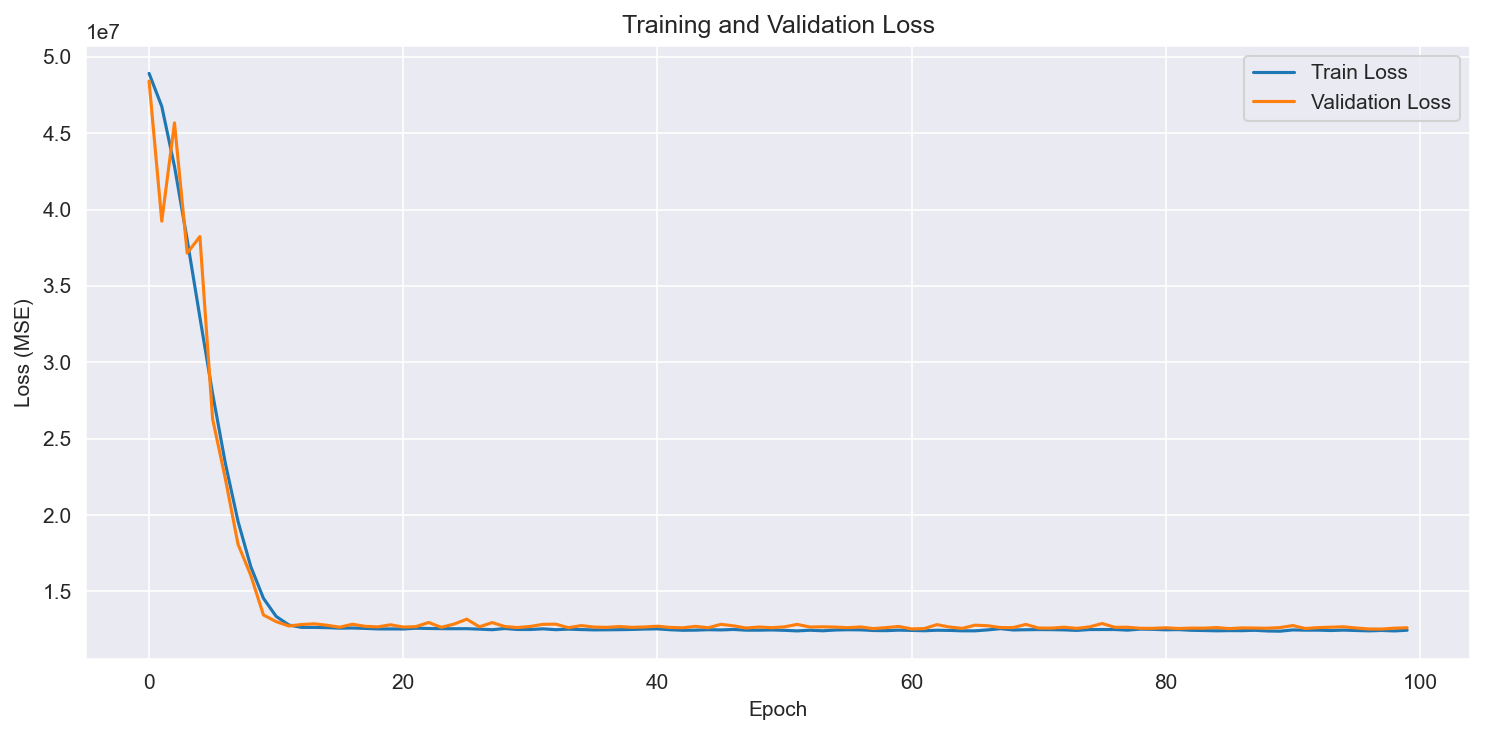

In [39]:
history = model.fit(
    X_train_transformed,
    y_train, 
    validation_split=0.2, 
    epochs=100,
    verbose=0,
    shuffle=True, 
    batch_size=64
)

plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [42]:
loss, mae = model.evaluate(X_test_transformed, y_test)
print(f'MAE: {mae}')

239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 638us/step - loss: 12582015.0000 - mae: 2815.3855
MAE: 2790.647705078125
